# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">کتابخانه های لازم </div>

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn import pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,classification_report,f1_score,roc_auc_score,log_loss,roc_curve
  

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بارگذاری داده ها</div>

In [2]:
df = pd.read_csv('enhanced_anxiety_dataset.csv')
df

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بررسی اولیه متغیر ها</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بررسی مقادیر گم شده هر ستون </div>

In [4]:
df.isna().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بررسی چند آماره برای ویژگی ها </div>

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,11000.0,40.241727,13.236140,18.0,29.0,40.0,51.0,64.0
Sleep Hours,11000.0,6.650691,1.227509,2.3,5.9,6.7,7.5,11.3
Physical Activity (hrs/week),11000.0,2.942136,1.827825,0.0,1.5,2.8,4.2,10.1
Caffeine Intake (mg/day),11000.0,286.090000,144.813157,0.0,172.0,273.0,382.0,599.0
Alcohol Consumption (drinks/week),11000.0,9.701636,5.689713,0.0,5.0,10.0,15.0,19.0
Stress Level (1-10),11000.0,5.856364,2.927202,1.0,3.0,6.0,8.0,10.0
Heart Rate (bpm),11000.0,90.916000,17.325721,60.0,76.0,92.0,106.0,119.0
Breathing Rate (breaths/min),11000.0,20.957545,5.160107,12.0,17.0,21.0,25.0,29.0
Sweating Level (1-5),11000.0,3.080636,1.398877,1.0,2.0,3.0,4.0,5.0
Therapy Sessions (per month),11000.0,2.427818,2.183106,0.0,1.0,2.0,4.0,12.0


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;"> بررسی مقادیر موجود در ستون مثلا (شغل) </div>

In [6]:
df['Occupation'].value_counts()

Occupation
Musician      892
Artist        888
Student       878
Nurse         861
Chef          858
Doctor        842
Other         840
Freelancer    838
Engineer      833
Scientist     832
Athlete       822
Lawyer        809
Teacher       807
Name: count, dtype: int64

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بررسی توزیع متغیر پاسخ  برای توزیع مناسب در <code>train, test</code></div>

<Axes: ylabel='Frequency'>

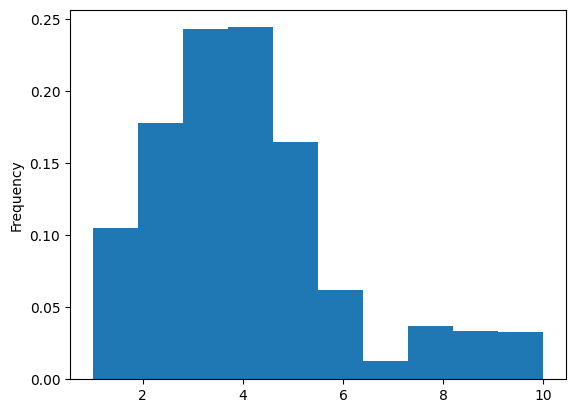

In [7]:
df['Anxiety Level (1-10)'].plot(kind='hist',density = 'TRUE')

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">باینری کردن متغیر پاسخ و تعیین متغیر های ورودی</div>

In [8]:
X = df.drop('Anxiety Level (1-10)',axis=1)
df['Anxiety Level_bin'] = df['Anxiety Level (1-10)'].apply(lambda x : 1 if x >=5 else 0)
Y = df['Anxiety Level_bin']
Y.value_counts()

Anxiety Level_bin
0    7618
1    3382
Name: count, dtype: int64

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ساخت لیست ستون های کمی و کیفی</div>

In [9]:
num_cols = X.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.to_list()
print('cat_col:\n',cat_cols,'\n','num_col:\n',num_cols)

cat_col:
 ['Gender', 'Occupation', 'Smoking', 'Family History of Anxiety', 'Dizziness', 'Medication', 'Recent Major Life Event'] 
 num_col:
 ['Age', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Therapy Sessions (per month)', 'Diet Quality (1-10)']


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم ماتریس همبستگی </div>

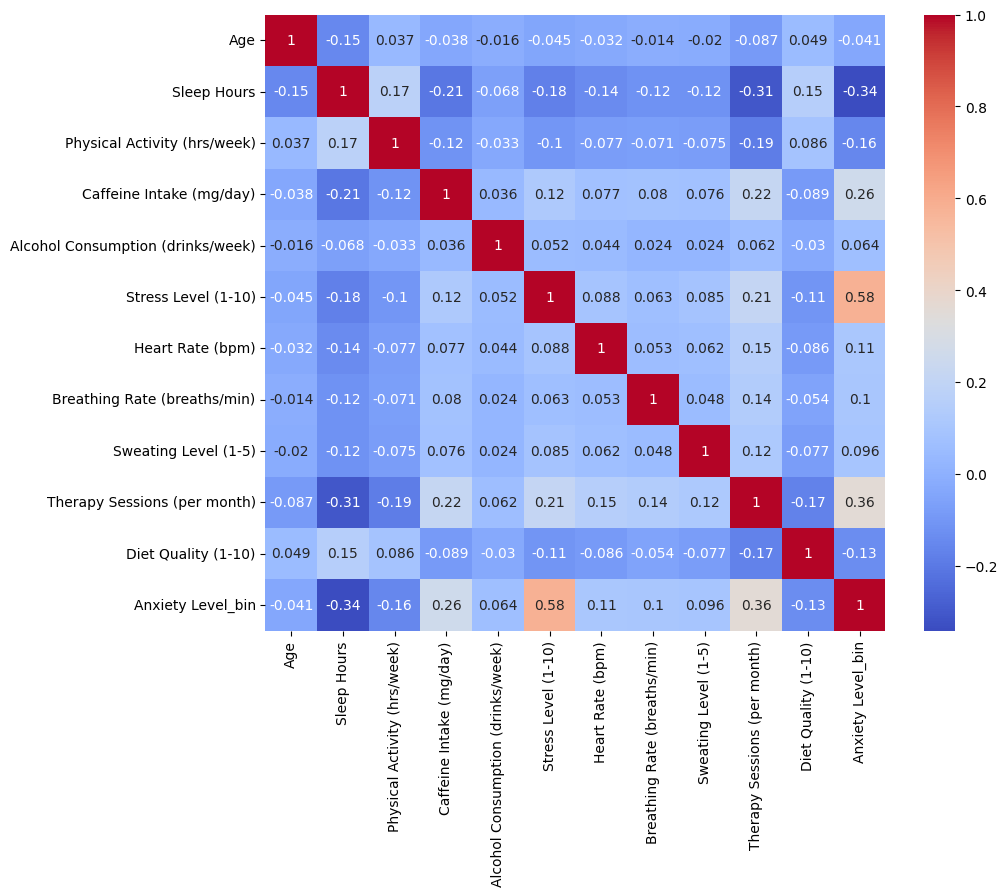

In [10]:
num_df = df[df.drop('Anxiety Level (1-10)',axis=1).select_dtypes(include=[np.number]).columns.to_list()]
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm");

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">بررسی حساسیت شغل ها</div>

In [11]:
df.groupby("Occupation")["Anxiety Level_bin"].mean().sort_values(ascending=False)


Occupation
Doctor        0.359857
Lawyer        0.359703
Engineer      0.352941
Scientist     0.344952
Freelancer    0.306683
Student       0.305239
Nurse         0.298490
Chef          0.298368
Athlete       0.283455
Artist        0.281532
Musician      0.281390
Other         0.269048
Teacher       0.258984
Name: Anxiety Level_bin, dtype: float64

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">تمیز کاری و تقسیم داده ها به <code>train, test</code> </div>

In [27]:
num_transformer = pipeline.Pipeline([('Imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_transformer = pipeline.Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('OHE',OneHotEncoder())])
preprocessor = ColumnTransformer(transformers=[('num_transformer',num_transformer,num_cols),('cat_transformer',cat_transformer,cat_cols)],
                                 remainder='drop')

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state= 42 ,stratify=Y)

X_train_tra = preprocessor.fit_transform(X_train)
X_test_tra = preprocessor.transform(X_test)
X_train_tra.shape

(8800, 37)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">اعمال <code>PCA</code></div>

In [13]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_tra)
X_test_pca = pca.transform(X_test_tra)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم داده های آموزشی در برابر تست </div>

C:\Users\Sina\AppData\Local\Temp\ipykernel_25140\3457402341.py:4: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[:,0],X_test_pca[:,1],c=Y_test, cmap='coolwarm', alpha=0.9, label='Test', edgecolor='none',marker='x')


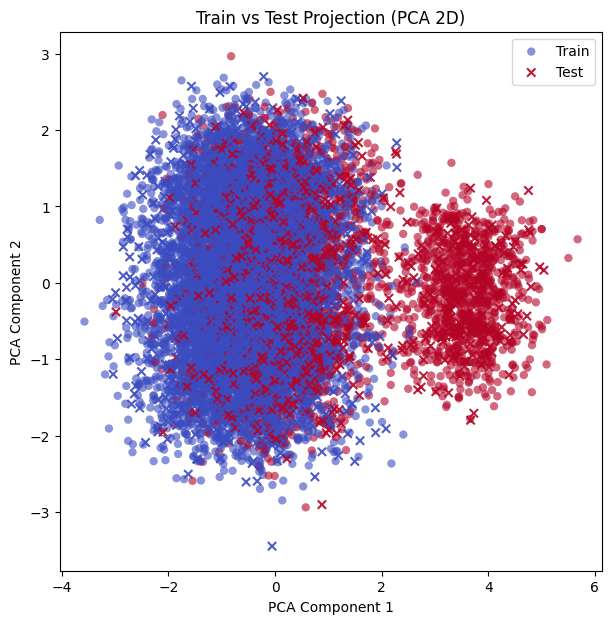

In [14]:
plt.figure(figsize=(7,7))

plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c= Y_train, cmap='coolwarm', alpha=0.6, label='Train', edgecolor='none')
plt.scatter(X_test_pca[:,0],X_test_pca[:,1],c=Y_test, cmap='coolwarm', alpha=0.9, label='Test', edgecolor='none',marker='x')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Train vs Test Projection (PCA 2D)')
plt.legend()
plt.show()


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ساخت کلاس رگسیون لوژستیک از ابتدا</div>

In [15]:
class LogisticRegressionScratch:
    """
    Binary Logistic Regression (from scratch) with Gradient Descent.

    Parameters
    ----------
    learning_rate : float
        نرخ یادگیری نزولی 
    epochs : int
        تعداد تکرار های آموزش 
    l2 : float 
        l2 ضریب regularizator
    fit_intercept : bool
        عرض از مبدا افزوده شود 
    batch_size : int or none
        اگر none  باشد فول بچ 
    tol : float 
        آستانه توقف زود هنگام بر اساس تغییرات لاس
    patience : int 
        توقف در صورت عدم بهبود یا بدتر شدن 
    random_state : int or none
        تاثیر تنها در مینی بچ

    """
    def __init__(self,learning_rate =0.1, epochs = 1000, l2 = 0.0,
                 fit_intercept =True, batch_size = None, tol = 1e-6, 
                 patience=20,random_state = None):
        self.lr = learning_rate
        self.epochs = epochs
        self.l2 = l2
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size 
        self.tol = tol
        self.patience = patience
        self.random_state = random_state

        self.w_ = None
        self.loss_history_ = []
        self.best_epoch_ = 0

    def _add_intercept(self,X):
        if not self.fit_intercept:
            return X
        return np.hstack([np.ones((X.shape[0],1)),X])
    
    @staticmethod
    def _sigmoid(z):
        z = np.clip(z,-500,500)
        return 1/ (1 + np.exp(-z))
    
    def _loss(self,Xb,y,w):
        
        p = self._sigmoid(Xb @ w)
        eps = 1e-12
        bce = -(y * np.log(p + eps) + (1-y) * np.log(1-p+eps)).mean()

        if self.fit_intercept:
            reg = 0.5 * self.l2 * np.sum(w[1:]**2)
        else : 
            reg = 0.5 * self.l2 * np.sum(w**2)
        
        return bce + reg
    
    def _gradient(self , Xb , y, w):
        p = self._sigmoid(Xb @ w )
        grad = (Xb.T @ (p-y))/Xb.shape[0]

        if self.l2>0 :
            if self.fit_intercept:
                grad[1:] += self.l2 * w[1:]
            else:
                grad += self.l2 * w

        return grad
    def fit(self,X,y):

        X = np.asanyarray(X,dtype=float)
        y = np.asanyarray(y, dtype= float).reshape(-1)
        Xb = self._add_intercept(X)
        n_feature = Xb.shape[1]
        rng = np.random.default_rng(self.random_state)
        self.w_ = np.zeros(n_feature)
        self.loss_history_.clear()
        best_loss = np.inf
        epochs_no_improve = 0
        

        for epoch in range(self.epochs):
            if self.batch_size is None :
                grad = self._gradient(Xb,y,self.w_)
                self.w_-= self.lr * grad
            else:
                idx = rng.permutation(Xb.shape[0])
                for start in range(0,Xb.shape[0],self.batch_size):
                    sl = idx[start:start+self.batch_size]
                    grad = self._gradient(Xb[sl],y[sl],self.w_)
                    self.w_-= self.lr * grad
            
            cur_loss = self._loss(Xb,y,self.w_)
            self.loss_history_.append(cur_loss)

            if cur_loss <best_loss - self.tol:
                best_loss = cur_loss
                self.best_epoch_ = epoch
                epochs_no_improve = 0
            else:
                epochs_no_improve+=1
                if epochs_no_improve>= self.patience:
                    break
        return self
    
    def decision_function(self,X):
        X = np.asanyarray(X,dtype=float)
        Xb = self._add_intercept(X)
        return Xb @ self.w_
    
    def predict_prob(self,X):
        return self._sigmoid(self.decision_function(X))
    
    def predict(self, X , threshold = 0.5):
        return (self.predict_prob(X)>= threshold).astype(int)
    def predict_proba(self,X):
        p1 = self.predict_prob(X)
        p0 = 1-p1
        return np.column_stack([p0,p1])
        

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">برازش سه مدل با مقادیر مختلف نرخ یادگیری (1),(0.5),(0.1) و رسم آن </div>

last_loss: 0.3629768233408449
best_epoch: 100
last_loss: 0.3435497035815862
best_epoch: 48
last_loss: 0.3419946948406606
best_epoch: 29


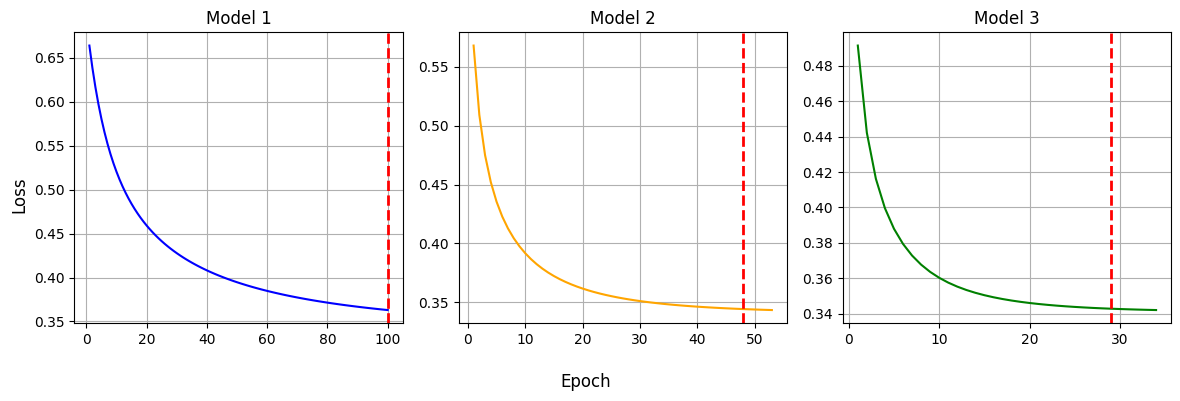

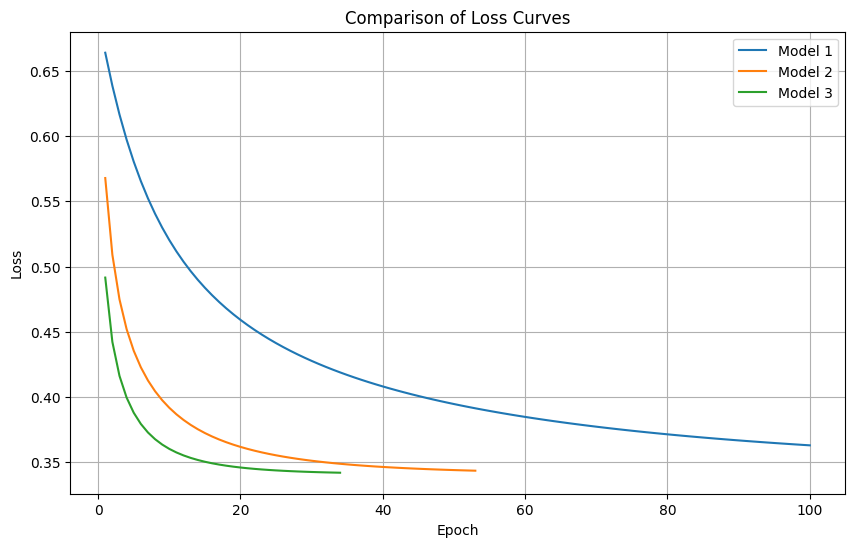

In [16]:
model_1 = LogisticRegressionScratch(learning_rate=0.1, epochs= 100, l2=0, fit_intercept= True,
                                   batch_size=None, tol=0.001, patience=5,random_state=42)
model_1.fit(X_train_tra,Y_train)
model_1.predict_prob(X_test_tra)
model_1.predict(X_test_tra)
print('last_loss:',model_1.loss_history_[-1])
print('best_epoch:',model_1.best_epoch_+1)

model_2 = LogisticRegressionScratch(learning_rate=0.5, epochs= 100, l2=0, fit_intercept= True,
                                   batch_size=None, tol=0.001, patience=5,random_state=42)
model_2.fit(X_train_tra,Y_train)
model_2.predict_prob(X_test_tra)
model_2.predict(X_test_tra)
print('last_loss:',model_2.loss_history_[-1])
print('best_epoch:',model_2.best_epoch_+1)

model_3 = LogisticRegressionScratch(learning_rate= 1, epochs= 100, l2=0, fit_intercept= True,
                                   batch_size=None, tol=0.001, patience=5,random_state=42)
model_3.fit(X_train_tra,Y_train)
model_3.predict_prob(X_test_tra)
model_3.predict(X_test_tra)
print('last_loss:',model_3.loss_history_[-1])
print('best_epoch:',model_3.best_epoch_+1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(range(1, 1+len(model_1.loss_history_)),model_1.loss_history_, color='blue')
axes[0].set_title("Model 1")
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=2)
axes[0].grid(True)

axes[1].plot(range(1, 1+len(model_2.loss_history_)),model_2.loss_history_, color='orange')
axes[1].set_title("Model 2")
axes[1].grid(True)
axes[1].axvline(x=48, color='red', linestyle='--', linewidth=2)

axes[2].plot(range(1, 1+len(model_3.loss_history_)),model_3.loss_history_, color='green')
axes[2].set_title("Model 3")
axes[2].grid(True)
axes[2].axvline(x=29, color='red', linestyle='--', linewidth=2)

fig.supxlabel("Epoch")
fig.supylabel("Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))
plt.plot(range(1, 1+len(model_1.loss_history_)),model_1.loss_history_, label="Model 1")
plt.plot(range(1, 1+len(model_2.loss_history_)),model_2.loss_history_, label="Model 2")
plt.plot(range(1, 1+len(model_3.loss_history_)),model_3.loss_history_, label="Model 3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparison of Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">برازش مدل <code>naive_bayes</code></div>

In [17]:
nb_model = GaussianNB()
nb_model.fit(X_train_tra,Y_train)
y_predict_nb = nb_model.predict(X_test_tra)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;"> برازش رگرسیون لوژستیک از کتابخانه آماده</div>

In [18]:
Log_model = LogisticRegression(random_state=42)
Log_model.fit(X_train_tra,Y_train)
y_predict_log = Log_model.predict(X_test_tra)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">ساخت تابع ارزیابی مدل ها </div>

In [19]:
def evaluate_all_models(models,models_names,X_test,Y_test):
    results = {
        'accuracy' : [],
        'precision' :[],
        'recall' : [],
        'specificity':[],
        'f1-score': [],
        'AUC':[],
        'log loss':[],
        'TN':[],'FP':[],'TP':[],'FN':[]
    }

    for model in models:
        y_predict = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
        TN, FP, TP, FN = confusion_matrix(Y_test,y_predict).ravel()
        specificity = TN / (TN + FP)

        results['accuracy'].append(accuracy_score(Y_test,y_predict))
        results['precision'].append(precision_score(Y_test,y_predict))
        results['recall'].append(recall_score(Y_test,y_predict))
        results['specificity'].append(specificity)
        results['f1-score'].append(f1_score(Y_test,y_predict))
        results['AUC'].append(roc_auc_score(Y_test,y_predict))
        results['log loss'].append(log_loss(Y_test,y_predict))
        results['TN'].append(TN)
        results['FP'].append(FP)
        results['TP'].append(TP)
        results['FN'].append(FN)
    
    df = pd.DataFrame(results,index=models_names)
    return df


In [20]:
models = [model_1, model_2, model_3, nb_model, Log_model]
names = ['LogisticRegressionScratch(lr = 0.1)','LogisticRegressionScratch(lr = 0.5)','LogisticRegressionScratch(lr = 1)',
         'naive_bayes','Logistic_regression_sklearn']
df_2 = evaluate_all_models(models=models,models_names=names,X_test=X_test_tra,Y_test=Y_test)
df_2

,accuracy,precision,recall,specificity,f1-score,AUC,log loss,TN,FP,TP,FN
LogisticRegressionScratch(lr = 0.1),0.826818,0.810526,0.569527,0.940945,0.668983,0.755236,6.242105,1434,90,291,385
LogisticRegressionScratch(lr = 0.5),0.830455,0.775956,0.630178,0.919291,0.695510,0.774734,6.111038,1401,123,250,426
LogisticRegressionScratch(lr = 1),0.830455,0.771020,0.637574,0.916010,0.697976,0.776792,6.111038,1396,128,245,431
naive_bayes,0.809545,0.736648,0.591716,0.906168,0.656276,0.748942,6.864678,1381,143,276,400
Logistic_regression_sklearn,0.827273,0.755172,0.647929,0.906824,0.697452,0.777377,6.225722,1382,142,238,438


# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم منحنی <code>ROC</code></div>

In [21]:
def plot_roc_curves(models, model_names, X_test, y_test):
    plt.figure(figsize=(8,6))
    for model, name in zip(models, model_names):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)
    plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curves for Models")
    plt.legend()
    plt.grid(True)
    plt.show()

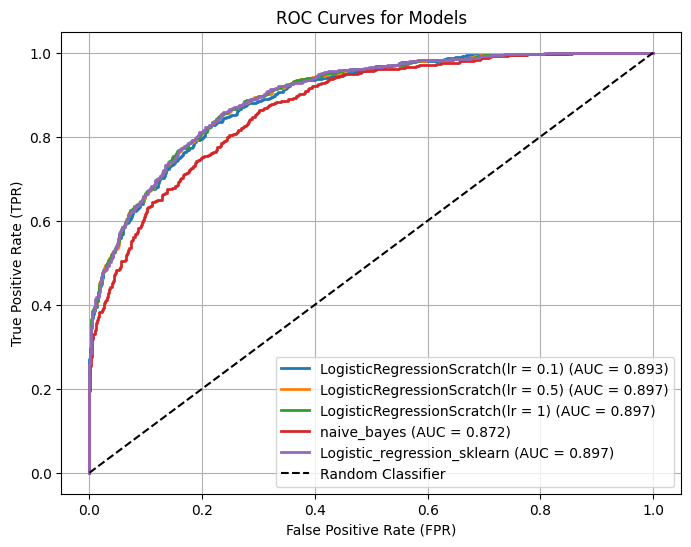

In [22]:
plot_roc_curves(models=models,model_names=names,X_test=X_test_tra,y_test=Y_test)

# <div dir = 'rtl' style="font-family: 'B Nazanin', 'IRANSans', 'Tahoma'; font-size: 40px; line-height: 1.8; text-align: justify;">رسم مرز تصمیم (با کمک <code>AI</code>)</div>

In [23]:
def plot_decision_boundaries(models, names, X_train_tra, y_train, pca, h=0.02):
    # 1. PCA transform (2D)
    X_train_2d = pca.transform(X_train_tra)

    # 2. make meshgrid in PCA space
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # 3. inverse transform -> original feature space
    grid_original = pca.inverse_transform(grid_2d)

    # 4. subplots
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()

    for ax, model, name in zip(axes, models, names):

        # 5. Predict using ORIGINAL model
        Z = model.predict(grid_original)
        Z = Z.reshape(xx.shape)

        # 6. plot boundary
        ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
        ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm", s=8)
        ax.set_title(name)

    plt.tight_layout()
    plt.show()


EVR: 0.21


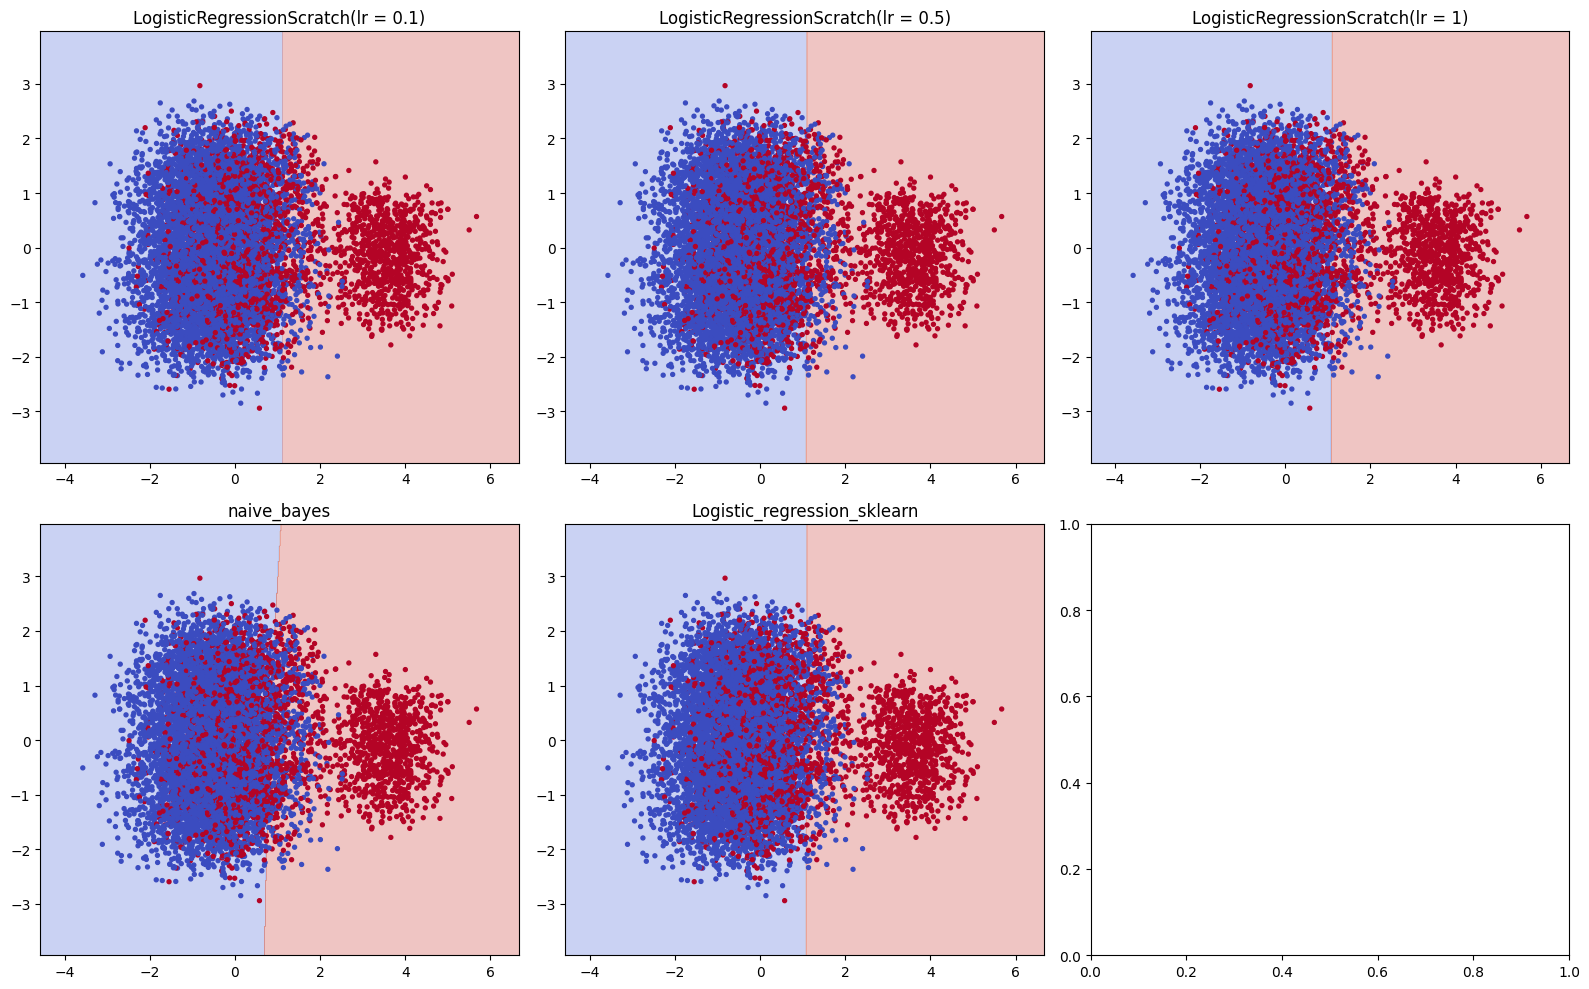

In [24]:
pca = PCA(n_components=2)
pca.fit(X_train_tra)
print("EVR:",pca.explained_variance_ratio_.sum().round(2))
plot_decision_boundaries(models, names, X_train_tra, Y_train, pca)
